#  Notebook 1 — Data Preparation
**Steps covered:**
1. Install dependencies
2. Inspect dataset structure
3. Validate & clean YOLO labels
4. Convert YOLO → COCO format (per split)
5. Verify COCO annotations

**Output:** `annotations.json` inside each split folder

---

In [ ]:
# ============================================================
#  CONFIG
# ============================================================
DATASET_BASE = "dataset"           
CLASSES = [                        
    "traffic light", "traffic sign", "car", "person", "bus",
    "truck", "rider", "bike", "motor", "train", "banner", "tuktuk"
]

VALID_CLASS_IDS = set(range(len(CLASSES))) 

SPLITS = {
    "train": f"{DATASET_BASE}/train/train",
    "val"  : f"{DATASET_BASE}/val/val",
    "test" : f"{DATASET_BASE}/test/test",
}

print(f"Dataset base : {DATASET_BASE}")
print(f"Classes ({len(CLASSES)}): {CLASSES}")

Dataset base : dataset
Classes (12): ['traffic light', 'traffic sign', 'car', 'person', 'bus', 'truck', 'rider', 'bike', 'motor', 'train', 'banner', 'tuktuk']


## Step 1 — Install Dependencies

In [2]:
# Uncomment to install
# !pip install -q opencv-python imagesize tqdm

## Step 2 — Inspect Dataset Structure

In [ ]:
import os

print("Dataset split summary:")
print("-" * 55)
total_imgs = total_lbls = 0
for split, path in SPLITS.items():
    img_dir = os.path.join(path, "images")
    lbl_dir = os.path.join(path, "labels")
    imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    lbls = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
    ann  = os.path.join(path, "annotations.json")
    ann_status = f"({os.path.getsize(ann)/1024**2:.1f} MB)" if os.path.exists(ann) else " not yet generated"
    print(f"{split:6s} | images: {imgs:6d} | labels: {lbls:6d} | annotations.json: {ann_status}")
    total_imgs += imgs; total_lbls += lbls
print("-" * 55)
print(f"{'TOTAL':6s} | images: {total_imgs:6d} | labels: {total_lbls:6d}")

#  sample label
sample_lbl_dir = os.path.join(SPLITS["train"], "labels")
sample_lbl = os.listdir(sample_lbl_dir)[0]
print(f"\nSample label file: {sample_lbl}")
with open(os.path.join(sample_lbl_dir, sample_lbl)) as f:
    print(f.read()[:300])

Dataset split summary:
-------------------------------------------------------
train  | images:  48329 | labels:  48329 | annotations.json: ✅ (43.2 MB)
val    | images:   6278 | labels:   6278 | annotations.json: ✅ (5.4 MB)
test   | images:   5805 | labels:   5805 | annotations.json: ✅ (5.2 MB)
-------------------------------------------------------
TOTAL  | images:  60412 | labels:  60412

Sample label file: -5292-67-95-_Moment-10-_jpg.rf.956075bd58efbf17606e35e9573cb65f.txt
4 0.49296875 0.48671875 0.665625 0.73046875
2 0.9125 0.478125 0.13671875 0.16328125


## Step 3 — Validate & Clean YOLO Labels
> Removes label files with invalid format and their corresponding images.

In [ ]:
import os
from pathlib import Path

DRY_RUN = True   # set to False to actually delete invalid files

def is_valid_label(label_path, valid_classes):
    """Check if a YOLO label file is valid."""
    try:
        with open(label_path, 'r') as f:
            for line_num, line in enumerate(f, 1):
                parts = line.strip().split()
                if not parts: continue  # skip empty lines
                if len(parts) != 5:
                    return False, f"line {line_num}: expected 5 elements, got {len(parts)}"
                try:
                    cls_id = int(parts[0])
                    if cls_id not in valid_classes:
                        return False, f"line {line_num}: invalid class ID {cls_id}"
                except ValueError:
                    return False, f"line {line_num}: non-integer class ID '{parts[0]}'"
                try:
                    coords = list(map(float, parts[1:]))
                    if any(not (0.0 <= x <= 1.0) for x in coords):
                        return False, f"line {line_num}: coordinates out of [0,1] range"
                except ValueError:
                    return False, f"line {line_num}: non-float coordinates"
        return True, "ok"
    except Exception as e:
        return False, str(e)

def validate_and_clean_split(split_path, valid_classes, dry_run=True):
    img_dir = Path(os.path.join(split_path, "images"))
    lbl_dir = Path(os.path.join(split_path, "labels"))

    removed_imgs = removed_lbls = missing_lbls = 0
    errors = []

    for lbl_file in lbl_dir.glob("*.txt"):
        valid, reason = is_valid_label(lbl_file, valid_classes)
        if not valid:
            errors.append((lbl_file.name, reason))
            # Find corresponding image
            for ext in [".jpg", ".jpeg", ".png"]:
                img_file = img_dir / (lbl_file.stem + ext)
                if img_file.exists():
                    if not dry_run:
                        img_file.unlink()
                    removed_imgs += 1
                    break
            if not dry_run:
                lbl_file.unlink()
            removed_lbls += 1

    # Check for images without labels
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        for img_file in img_dir.glob(ext):
            lbl_file = lbl_dir / (img_file.stem + ".txt")
            if not lbl_file.exists():
                missing_lbls += 1

    return removed_imgs, removed_lbls, missing_lbls, errors

print(f"{'DRY RUN' if DRY_RUN else 'LIVE RUN — files will be deleted!'}\n")
print(f"{'Split':<8} {'Invalid Labels':>14} {'Imgs Removed':>14} {'Missing Labels':>15}")
print("-" * 55)

for split, path in SPLITS.items():
    r_imgs, r_lbls, miss, errs = validate_and_clean_split(path, VALID_CLASS_IDS, dry_run=DRY_RUN)
    print(f"{split:<8} {r_lbls:>14} {r_imgs:>14} {miss:>15}")
    if errs and len(errs) <= 5:
        for fname, reason in errs:
            print(f"         ↳ {fname}: {reason}")
    elif errs:
        print(f"         ↳ ... and {len(errs)} more issues")


DRY RUN

Split    Invalid Labels   Imgs Removed  Missing Labels
-------------------------------------------------------
train               974            974               0
         ↳ ... and 974 more issues
val                 153            153               0
         ↳ ... and 153 more issues
test                128            128               0
         ↳ ... and 128 more issues

💡 Set DRY_RUN = False to actually remove invalid files.


## Step 4 — Convert YOLO → COCO Format
> **Run only once!** Auto-skips if `annotations.json` already exists.
> Takes ~90 min for 48k images (reads every image for dimensions).

In [5]:
import os, json, cv2
from tqdm import tqdm

def yolo_to_coco(split_path, split_name, classes):
    img_dir  = os.path.join(split_path, "images")
    lbl_dir  = os.path.join(split_path, "labels")
    out_path = os.path.join(split_path, "annotations.json")

    if os.path.exists(out_path):
        size_mb = os.path.getsize(out_path) / 1024**2
        print(f"⏭️  {split_name}: already exists ({size_mb:.1f} MB) — skipping")
        return

    coco = {
        "info": {"description": f"Egypt Autonomous Cars Dataset — {split_name}"},
        "categories": [{"id": i, "name": n} for i, n in enumerate(classes)],
        "images": [], "annotations": []
    }
    ann_id = 0
    img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])

    for img_id, img_file in enumerate(tqdm(img_files, desc=f"Converting {split_name}")):
        img = cv2.imread(os.path.join(img_dir, img_file))
        if img is None: continue
        h, w = img.shape[:2]
        coco["images"].append({"id": img_id, "file_name": img_file, "width": w, "height": h})

        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_file)[0] + ".txt")
        if not os.path.exists(lbl_path): continue

        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5: continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])
                abs_w = bw * w; abs_h = bh * h
                abs_x = cx * w - abs_w / 2
                abs_y = cy * h - abs_h / 2
                coco["annotations"].append({
                    "id": ann_id, "image_id": img_id, "category_id": cls_id,
                    "bbox": [abs_x, abs_y, abs_w, abs_h],
                    "area": abs_w * abs_h, "iscrowd": 0
                })
                ann_id += 1

    with open(out_path, "w") as f:
        json.dump(coco, f)
    print(f"✅ {split_name}: {len(coco['images'])} images, {len(coco['annotations'])} annotations → {out_path}")

for name, path in SPLITS.items():
    yolo_to_coco(path, name, CLASSES)

⏭️  train: already exists (43.2 MB) — skipping
⏭️  val: already exists (5.4 MB) — skipping
⏭️  test: already exists (5.2 MB) — skipping


## Step 5 — Verify COCO Annotations

Split      Images   Annotations   Categories   Avg Ann/Img
----------------------------------------------------------
train       48329        284177           12           5.9
val          6278         36010           12           5.7
test         5805         34529           12           5.9


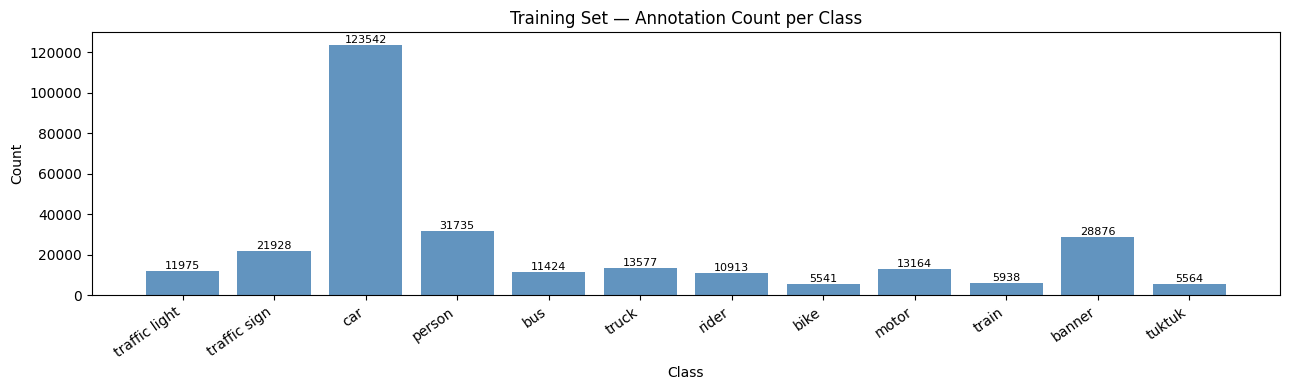

In [8]:
import json, os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

print(f"{'Split':<8} {'Images':>8} {'Annotations':>13} {'Categories':>12} {'Avg Ann/Img':>13}")
print("-" * 58)

for split, path in SPLITS.items():
    ann_path = os.path.join(path, "annotations.json")
    if not os.path.exists(ann_path):
        print(f"{split:<8}  annotations.json not found")
        continue
    with open(ann_path) as f:
        coco = json.load(f)
    n_imgs = len(coco["images"])
    n_anns = len(coco["annotations"])
    n_cats = len(coco["categories"])
    avg    = n_anns / max(n_imgs, 1)
    print(f"{split:<8} {n_imgs:>8} {n_anns:>13} {n_cats:>12} {avg:>13.1f}")

# Class distribution chart for train split
train_ann_path = os.path.join(SPLITS["train"], "annotations.json")
if os.path.exists(train_ann_path):
    with open(train_ann_path) as f:
        coco = json.load(f)
    cat_map = {c["id"]: c["name"] for c in coco["categories"]}
    counts  = Counter(a["category_id"] for a in coco["annotations"])
    labels  = [cat_map[i] for i in sorted(counts)]
    vals    = [counts[i]  for i in sorted(counts)]

    fig, ax = plt.subplots(figsize=(13, 4))
    bars = ax.bar(labels, vals, color='steelblue', alpha=0.85)
    ax.bar_label(bars, fmt='%d', fontsize=8)
    ax.set_title("Training Set — Annotation Count per Class")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    # plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()